# Industry analysis

In [1]:
import numpy as np
import pandas as pd
import ast
import networkx as nx
from tqdm import tqdm
import pickle

In [39]:
def get_attr(nodes, G, func):
    attr = {}
    for node in nodes:
        attr[node] = func(G.nodes[node])
    return attr

In [7]:
# import graph
with open(r"C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\graph\industry.pkl", "rb") as f:
    G = pickle.load(f)

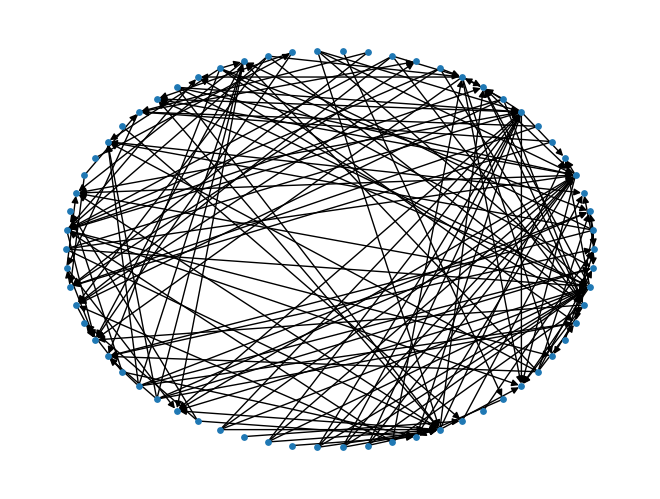

In [10]:
nx.draw_shell(G, node_size=15)

## industry geographic location

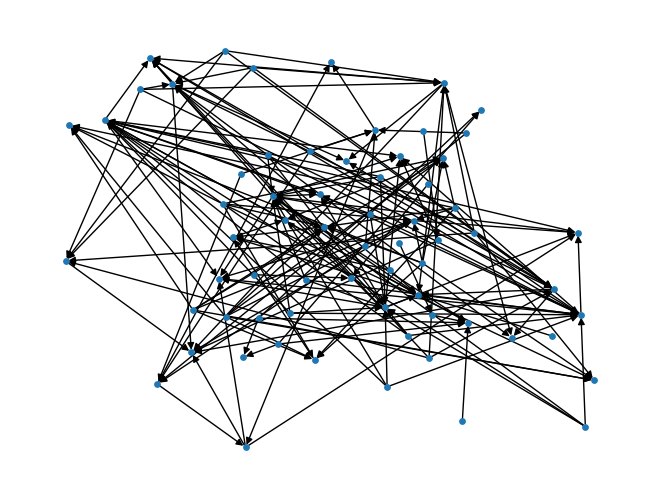

In [41]:
pos = get_attr(G.nodes, G, lambda x: (x['x'], x['y']))
nx.draw(G, pos=pos, node_size=15)

In [27]:

between_df = pd.DataFrame({
    'node': list(nx.betweenness_centrality(G).keys()),
    'betweenness_centrality': list(nx.betweenness_centrality(G).values())
})
between_df = between_df.loc[between_df['betweenness_centrality']!=0]
between_node = between_df.node.to_list()

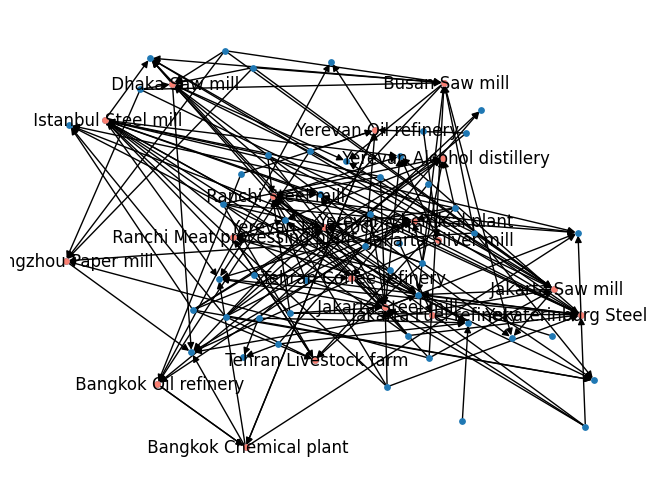

In [47]:
pos = get_attr(G.nodes, G, lambda x: (x['x'], x['y']))
nx.draw(G, pos=pos, node_size=15)
pos = get_attr(between_node, G, lambda x: (x['x'], x['y']))
labels = get_attr(between_node, G, lambda x: x['name'])
nx.draw(G.subgraph(between_node), pos=pos, 
        labels=labels, with_labels=True,
        node_size=15, node_color='salmon')

In [29]:
G.nodes[7838 ]

{'name': ' Ranchi Iron ore mine',
 'x': -1588.0,
 'y': 3072.0,
 'z': 1.8,
 'confile': 'iron_ore_mine.con',
 'input_material': {},
 'input_proportion': [{}],
 'output_material': ['IRON_ORE'],
 'output_proportion': [1],
 'capacity': 400}

In [21]:
between_df['betweenness_centrality'].sum()

np.float64(0.036778846153846155)